Install and imports

In [ ]:
!pip install ultralytics supervision -q

import os, glob, time, zipfile, yaml, re, random, shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from collections import Counter
from ultralytics import YOLO
import supervision as sv

random.seed(42)

Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


extract dataset

In [ ]:
zip_path = "/content/drive/MyDrive/Complete Food.v1-yolov8-obb.zip"   # update if your filename/path differs
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print(os.listdir(extract_path))

['README.roboflow.txt', 'test', 'valid', 'README.dataset.txt', 'train', 'data.yaml']


Fix data.yaml class names

In [ ]:
yaml_path = f"{extract_path}/data.yaml"

raw = zipfile.ZipFile(zip_path).read('data.yaml').decode()
found = {int(m.group(1)): m.group(2).strip().strip('"').strip("'")
         for m in re.finditer(r'^[ \t]+(\d+):[ \t]*(.*)$', raw, re.M)}
names = [found.get(i) if found.get(i) not in (None, '', '-') else f'class_{i}'
         for i in range(max(found) + 1)]
print(len(names), "classes:", names)

214 classes: ['Apple', 'Apple Pie', 'Avocado', 'Banana', 'Basil Rice', 'Beetroot', 'Bell Pepper', 'Bread', 'Broccoli', 'Bualoy', 'Burger', 'Cabbage', 'Cake', 'Carrot', 'Cauliflower', 'Cheese', 'Cheesecake', 'Chicken', 'Chicken Rice', 'Coconut', 'Coke', 'Cookie', 'Corn', 'Crispy Pork Kale', 'Croissant', 'Donut', 'Egg', 'Eggplant', 'Fig', 'Fish', 'French Fries', 'Grape', 'Grapefruit', 'Green Curry', 'Grilled Chicken', 'Hamburger', 'Homok', 'Hot Dog', 'Ice Cream', 'Jackfruit', 'Japanese-style-pancake', 'Jok', 'Juice', 'Khao kha moo', 'Laab', 'Laadna', 'Lemon', 'Lettuce', 'Macaron', 'Mango', 'Muffin', 'Mushroom', 'Namprig', 'Omelette', 'Orange', 'Padthai', 'Pancake', 'Papaya Salad', 'Pasta', 'Peach', 'Pear', 'Peas', 'Pineapple', 'Pizza', 'Pomegranate', 'Popcorn', 'Pork Satay', 'Potato', 'Pretzel', 'Pumpkin', 'Radish', 'Rice', 'Salad', 'Salmon', 'Sandwich', 'Shrimp', 'Spinach', 'Steak', 'Strawberry', 'Sukee', 'Sweet Potato', 'Tiramisu', 'Tom Yum', 'Tomato', 'Waffle', 'Watermelon', 'Zucchini

Inventory the dataset and verify a proper, reproducible split

In [ ]:

all_images = []
for split in ['train', 'valid', 'test']:
    all_images += glob.glob(f"{extract_path}/{split}/images/*")

print("Total images found:", len(all_images))

def label_path_for(img_path):
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

# Check class distribution across the whole pool
class_counts = Counter()
for img in all_images:
    lp = label_path_for(img)
    if os.path.exists(lp):
        for line in open(lp):
            if line.strip():
                class_counts[int(line.split()[0])] += 1

print("\nPer-class instance counts (top 10 and bottom 10):")
sorted_counts = sorted(class_counts.items(), key=lambda x: -x[1])
for idx, count in sorted_counts[:10]:
    print(f"  {names[idx]:20} {count}")
print("  ...")
for idx, count in sorted_counts[-10:]:
    print(f"  {names[idx]:20} {count}")

Total images found: 38730

Per-class instance counts (top 10 and bottom 10):
  Orange               9429
  Apple                5074
  Tomato               4768
  Grape                4436
  Strawberry           3671
  Banana               3154
  Rice                 2866
  Carrot               2032
  Pumpkin              1974
  Pasta                1702
  ...
  Crispy Pork Kale     17
  Namprig              16
  Green Curry          16
  Bualoy               15
  Sukee                15
  Padthai              15
  middle east burger   15
  Basil Rice           14
  bakso                10
  Cheesecake           7


Sanity check

Train: 27130 | Valid: 7749 | Test: 3851


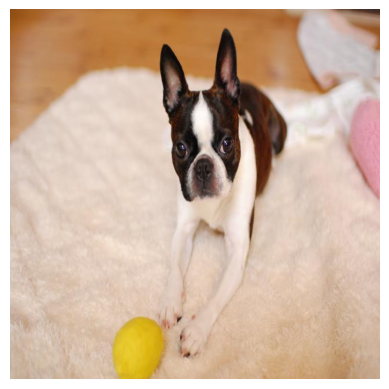

In [ ]:
img_files = glob.glob(f"{extract_path}/train/images/*")
print("Train:", len(img_files), "| Valid:", len(glob.glob(f"{extract_path}/valid/images/*")), "| Test:", len(glob.glob(f"{extract_path}/test/images/*")))

img = cv2.cvtColor(cv2.imread(img_files[0]), cv2.COLOR_BGR2RGB)
plt.imshow(img); plt.axis('off'); plt.show()

Rebuild a clean 80/10/10 split

In [ ]:
random.shuffle(all_images)
n = len(all_images)
train_split = all_images[:int(0.8 * n)]
val_split = all_images[int(0.8 * n):int(0.9 * n)]
test_split = all_images[int(0.9 * n):]

print(f"Train: {len(train_split)} | Val: {len(val_split)} | Test: {len(test_split)}")

clean_root = "/content/dataset_clean"
for split_name, split_files in [('train', train_split), ('val', val_split), ('test', test_split)]:
    os.makedirs(f"{clean_root}/{split_name}/images", exist_ok=True)
    os.makedirs(f"{clean_root}/{split_name}/labels", exist_ok=True)
    for img in split_files:
        shutil.copy(img, f"{clean_root}/{split_name}/images/")
        lp = label_path_for(img)
        if os.path.exists(lp):
            shutil.copy(lp, f"{clean_root}/{split_name}/labels/")

data_cfg = {
    'path': clean_root,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': len(names),
    'names': names,
}
yaml_path = f"{clean_root}/data.yaml"
yaml.safe_dump(data_cfg, open(yaml_path, 'w'), sort_keys=False)
print("Clean dataset ready at:", clean_root)

Train: 30984 | Val: 3873 | Test: 3873
Clean dataset ready at: /content/dataset_clean


Train (YOLOv8m, OBB) Dataset

In [ ]:
import os, glob

SKIP_TRAINING_IF_EXISTS = True
existing_models = glob.glob('/content/drive/MyDrive/food_runs/**/best.pt', recursive=True)

if SKIP_TRAINING_IF_EXISTS and existing_models:
    best_model_path = max(existing_models, key=os.path.getmtime)
    trained_model = YOLO(best_model_path)
    print(f"Skipping training — using existing model: {best_model_path}")
    SKIP_TRAINING = True
else:
    print("No existing model found (or skip disabled) — training will run.")
    SKIP_TRAINING = False

Skipping training — using existing model: /content/drive/MyDrive/food_runs/obb_train_v2/weights/best.pt


In [ ]:
model = YOLO('yolov8m-obb.pt')

results = model.train(
    data=yaml_path,
    task='obb',
    epochs=150,
    patience=20,          # stops early if val metrics plateau, avoids wasted compute
    imgsz=640,
    batch=32,
    optimizer='auto',
    cos_lr=True,
    project='/content/drive/MyDrive/food_runs',
    name='obb_train_v2',
    exist_ok=True
)

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset_clean/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=obb_train_v2, nbs=

POST-TRAINING metrics (validation split)

Run folder: /content/drive/MyDrive/food_runs/obb_train_v2


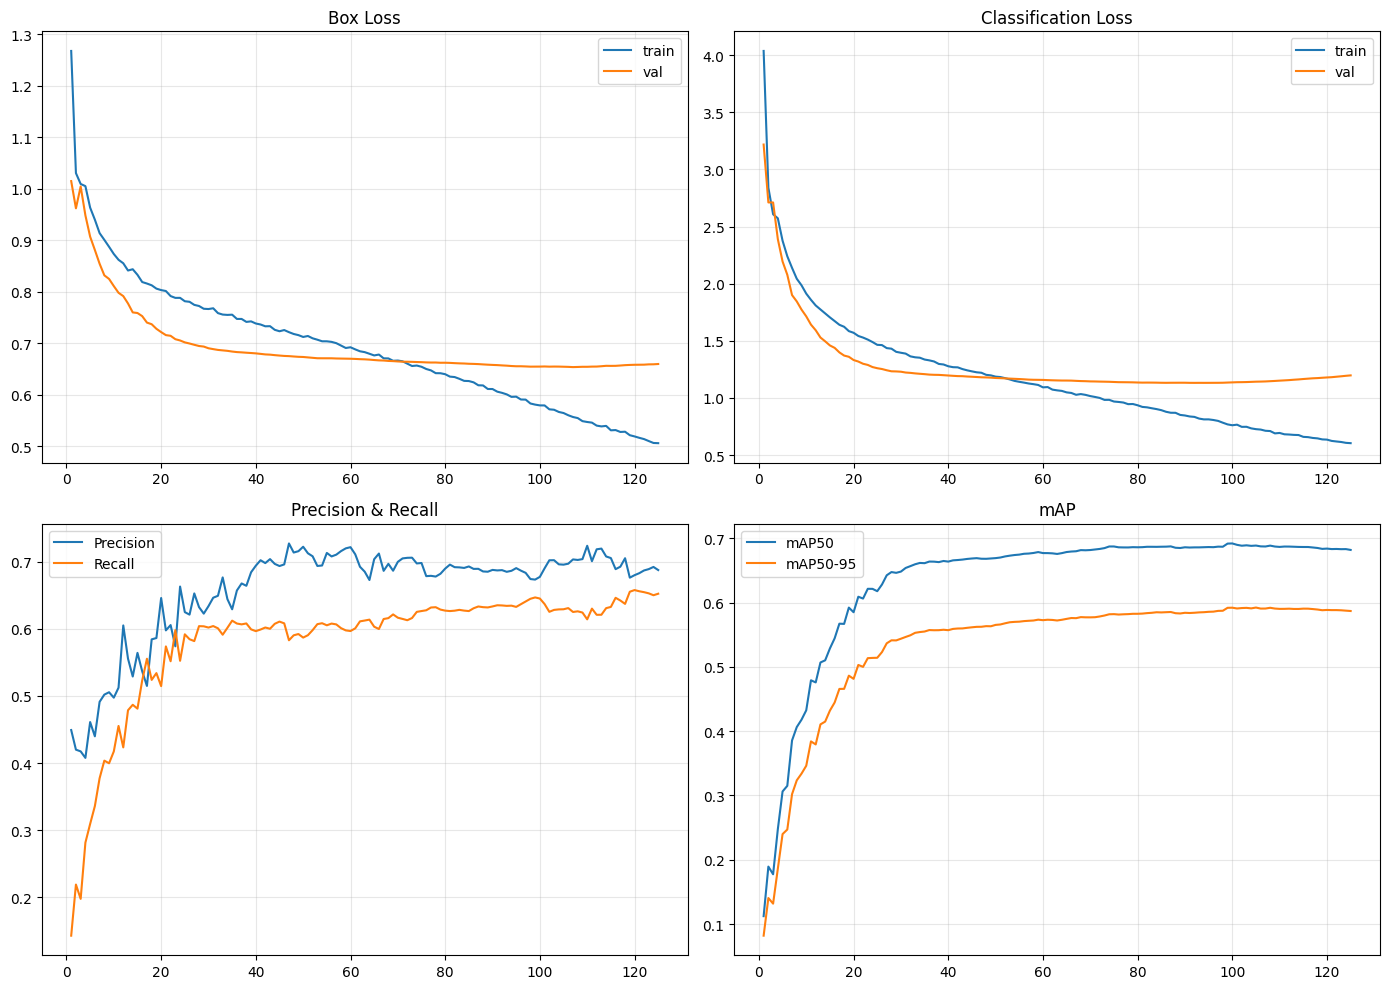

In [212]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Locate the training run folder (same one as your best.pt)
candidates = glob.glob('/content/drive/MyDrive/food_runs/**/best.pt', recursive=True)
best_model_path = max(candidates, key=os.path.getmtime)
run_dir = os.path.dirname(os.path.dirname(best_model_path))
print("Run folder:", run_dir)

results_csv = os.path.join(run_dir, "results.csv")
results_png = os.path.join(run_dir, "results.png")

if os.path.exists(results_csv):
    # Detailed per-epoch curves
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='train')
    axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='val')
    axes[0, 0].set_title('Box Loss'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='train')
    axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='val')
    axes[0, 1].set_title('Classification Loss'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
    axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
    axes[1, 0].set_title('Precision & Recall'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
    axes[1, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
    axes[1, 1].set_title('mAP'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

elif os.path.exists(results_png):
    # Fallback: Ultralytics' own pre-rendered summary image
    print("results.csv not found — showing Ultralytics' saved summary image instead.")
    plt.figure(figsize=(14, 8))
    plt.imshow(mpimg.imread(results_png))
    plt.axis('off')
    plt.title("Training Curves (box/cls/dfl loss, precision, recall, mAP over epochs)")
    plt.show()

else:
    print("Neither results.csv nor results.png found in this run folder.")
    print("Training history is unavailable for this run — files present:", os.listdir(run_dir))

In [213]:
import os, glob
from ultralytics import YOLO

candidates = glob.glob('/content/drive/MyDrive/food_runs/**/best.pt', recursive=True)
best_model_path = max(candidates, key=os.path.getmtime)
print("Using model:", best_model_path)

trained_model = YOLO(best_model_path)

train_metrics = trained_model.val(data=yaml_path, split='train', name='train', exist_ok=True, plots=True)

print("=" * 55)
print("TRAIN METRICS")
print("=" * 55)
print(f"mAP50      : {train_metrics.box.map50:.4f}")
print(f"mAP50-95   : {train_metrics.box.map:.4f}")
print(f"Precision  : {train_metrics.box.mp:.4f}")
print(f"Recall     : {train_metrics.box.mr:.4f}")
f1 = 2 * (train_metrics.box.mp * train_metrics.box.mr) / (train_metrics.box.mp + train_metrics.box.mr + 1e-9)
print(f"F1 Score   : {f1:.4f}")

Using model: /content/drive/MyDrive/food_runs/obb_train_v2/weights/best.pt
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLOv8m-obb summary (fused): 101 layers, 26,523,973 parameters, 0 gradients, 81.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3886.0±1685.4 MB/s, size: 54.1 KB)
val: Scanning /content/dataset_clean/train/labels.cache... 30984 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30984/30984 14.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1937/1937 15.9it/s 2:02
                   all      30984      78633      0.953      0.932      0.967      0.895
                 Apple       1149       3915      0.953      0.862      0.948      0.851
             Apple Pie        105        112      0.991       0.98      0.994      0.953
               Avocado        149        573       0.96      0.825      0.935      0.782

Detect and count on a test image

Total: 1
Per class: Counter({'Pancake': 1})


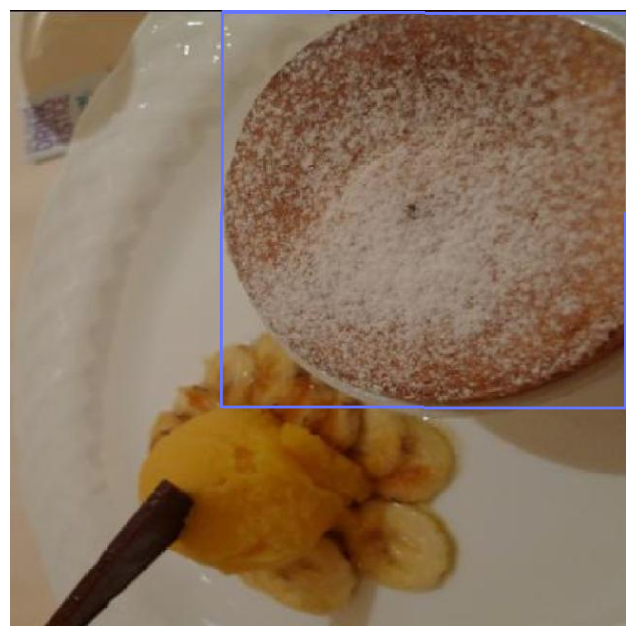

In [179]:
obb_annotator = sv.OrientedBoxAnnotator()
label_annotator = sv.LabelAnnotator()

test_img = glob.glob(f"{extract_path}/test/images/*")[0]
frame = cv2.imread(test_img)

result = trained_model(frame, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

labels = [f"{trained_model.names[c]} {conf:.2f}"
          for c, conf in zip(detections.class_id, detections.confidence)]

annotated = obb_annotator.annotate(scene=frame.copy(), detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

print("Total:", len(detections))
print("Per class:", Counter(trained_model.names[c] for c in detections.class_id))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.show()

own test image

Saving 71UbN9-gk8L.jpg to 71UbN9-gk8L (1).jpg
Detected: Counter({'Bell Pepper': 4})


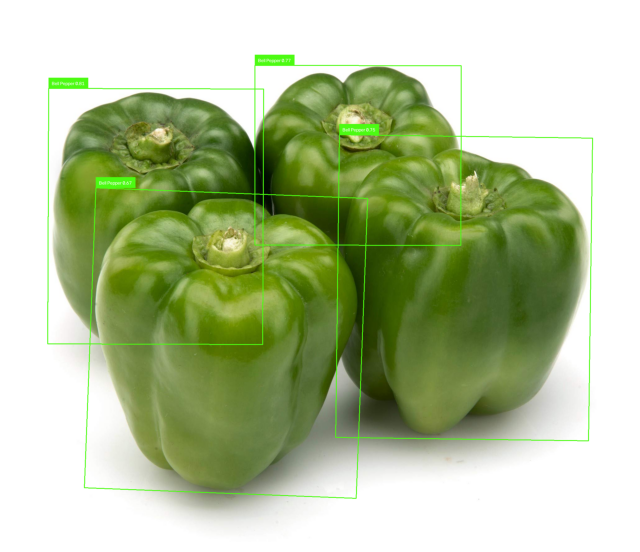

In [159]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]
frame = cv2.imread(img_path)

result = trained_model(frame, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)
labels = [f"{trained_model.names[c]} {conf:.2f}"
          for c, conf in zip(detections.class_id, detections.confidence)]

annotated = obb_annotator.annotate(scene=frame.copy(), detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

print("Detected:", Counter(trained_model.names[c] for c in detections.class_id))
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.show()

TEST SET metrics (final, held-out evaluation,unseen data)



In [214]:
import os, glob
from ultralytics import YOLO

candidates = glob.glob('/content/drive/MyDrive/food_runs/**/best.pt', recursive=True)
best_model_path = max(candidates, key=os.path.getmtime)
print("Using model:", best_model_path)

trained_model = YOLO(best_model_path)

# SEEN DATA — the model was directly trained on these images
train_metrics = trained_model.val(data=yaml_path, split='train', name='train', exist_ok=True, plots=True)

print("=" * 55)
print("TRAIN METRICS (seen data)")
print("=" * 55)
print(f"mAP50      : {train_metrics.box.map50:.4f}")
print(f"mAP50-95   : {train_metrics.box.map:.4f}")
print(f"Precision  : {train_metrics.box.mp:.4f}")
print(f"Recall     : {train_metrics.box.mr:.4f}")
f1_train = 2 * (train_metrics.box.mp * train_metrics.box.mr) / (train_metrics.box.mp + train_metrics.box.mr + 1e-9)
print(f"F1 Score   : {f1_train:.4f}")

# UNSEEN DATA — final evaluation
test_metrics = trained_model.val(data=yaml_path, split='test', name='test', exist_ok=True, plots=True)

print("=" * 55)
print("TEST METRICS (unseen data)")
print("=" * 55)
print(f"mAP50      : {test_metrics.box.map50:.4f}")
print(f"mAP50-95   : {test_metrics.box.map:.4f}")
print(f"Precision  : {test_metrics.box.mp:.4f}")
print(f"Recall     : {test_metrics.box.mr:.4f}")
f1_test = 2 * (test_metrics.box.mp * test_metrics.box.mr) / (test_metrics.box.mp + test_metrics.box.mr + 1e-9)
print(f"F1 Score   : {f1_test:.4f}")

Using model: /content/drive/MyDrive/food_runs/obb_train_v2/weights/best.pt
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLOv8m-obb summary (fused): 101 layers, 26,523,973 parameters, 0 gradients, 81.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4358.3±1347.5 MB/s, size: 55.2 KB)
val: Scanning /content/dataset_clean/train/labels.cache... 30984 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30984/30984 13.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1937/1937 16.0it/s 2:01
                   all      30984      78633      0.953      0.932      0.967      0.895
                 Apple       1149       3915      0.953      0.862      0.948      0.851
             Apple Pie        105        112      0.991       0.98      0.994      0.953
               Avocado        149        573       0.96      0.825      0.935      0.782

confusion matrix

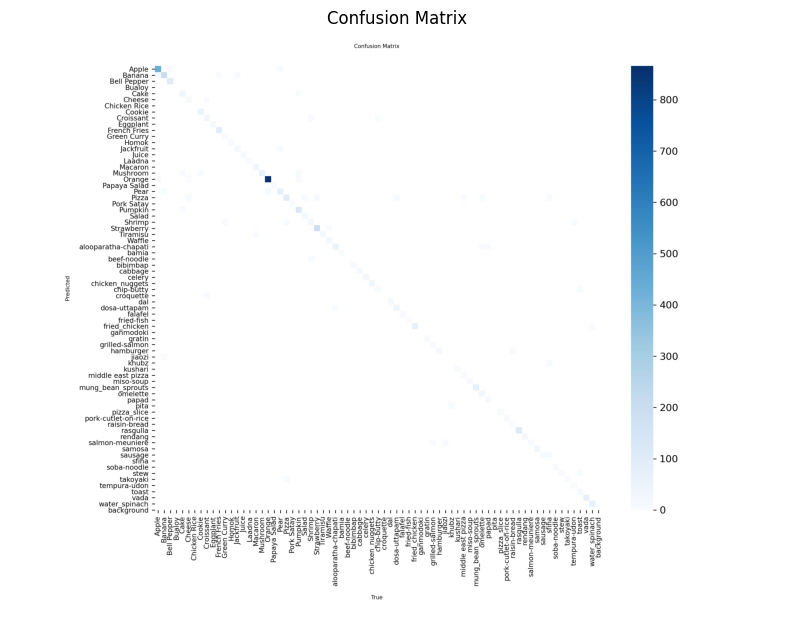

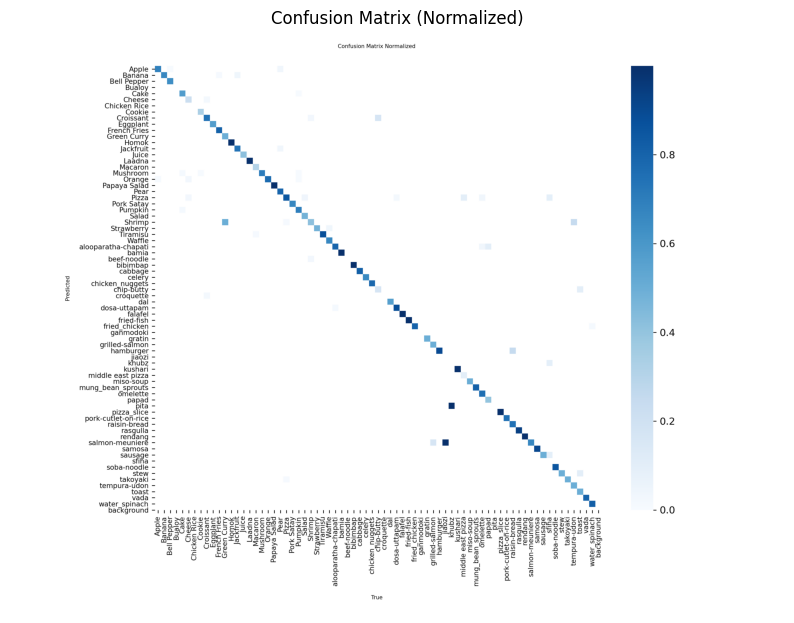

In [161]:
save_dir = str(test_metrics.save_dir)
for fname, title in [("confusion_matrix.png", "Confusion Matrix"),
                      ("confusion_matrix_normalized.png", "Confusion Matrix (Normalized)")]:
    path = os.path.join(save_dir, fname)
    if os.path.exists(path):
        plt.figure(figsize=(10, 8))
        plt.imshow(mpimg.imread(path))
        plt.axis('off')
        plt.title(title)
        plt.show()

validation matrics

In [211]:
import os, glob
from ultralytics import YOLO

candidates = glob.glob('/content/drive/MyDrive/food_runs/**/best.pt', recursive=True)
best_model_path = max(candidates, key=os.path.getmtime)
trained_model = YOLO(best_model_path)

yaml_candidates = glob.glob('/content/dataset_clean/data.yaml') or glob.glob('/content/dataset/data.yaml')
yaml_path = yaml_candidates[0]

metrics = trained_model.val(data=yaml_path, split='val', name='val', exist_ok=True)

cm = metrics.confusion_matrix.matrix
accuracy = cm.diagonal()[:-1].sum() / cm[:, :-1].sum()
f1 = 2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr + 1e-9)

print("=" * 60)
print("FINAL MODEL PERFORMANCE REPORT")
print("=" * 60)
print(f"Model: YOLOv8-OBB (fine-tuned)")
print(f"Dataset: {len(trained_model.names)} classes")
print("-" * 60)
print(f"mAP50 (standard detection benchmark) : {metrics.box.map50*100:.2f}%")
print(f"mAP50-95                             : {metrics.box.map*100:.2f}%")
print(f"Precision                            : {metrics.box.mp*100:.2f}%")
print(f"Recall                                : {metrics.box.mr*100:.2f}%")
print(f"F1 Score                              : {f1*100:.2f}%")
print(f"Classification Accuracy (derived)    : {accuracy*100:.2f}%")
print("=" * 60)
print("Note: mAP (mean Average Precision) is the standard evaluation")
print("metric for object detection models, as 'accuracy' alone is not")
print("well-defined when multiple objects, partial matches, and")
print("localization quality are involved.")
print("=" * 60)

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLOv8m-obb summary (fused): 101 layers, 26,523,973 parameters, 0 gradients, 81.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3432.1±1547.6 MB/s, size: 46.1 KB)
val: Scanning /content/dataset_clean/val/labels.cache... 3873 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3873/3873 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 243/243 15.3it/s 15.9s
                   all       3873      10329      0.697      0.627      0.689      0.592
                 Apple        156        524      0.797      0.719       0.79      0.708
             Apple Pie          8          8      0.622      0.875      0.859      0.773
               Avocado         21         54      0.861      0.648      0.716      0.551
                Banana        141        310      0.821      0.565      0.622    

Precision-Recall Curve

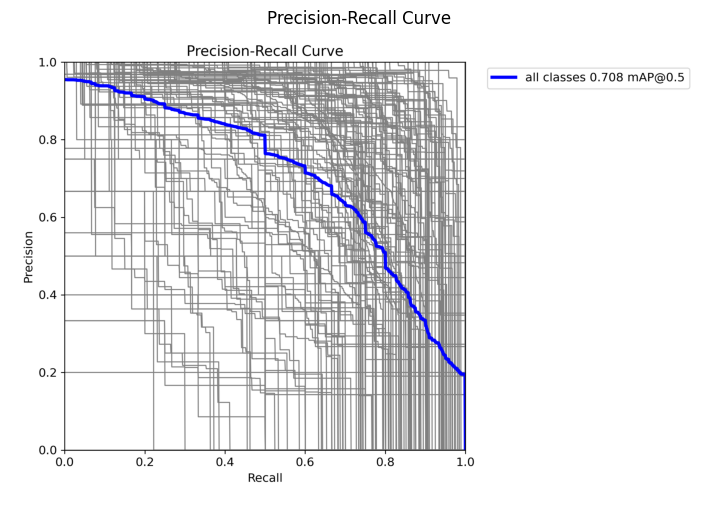

In [181]:
pr_path = os.path.join(str(test_metrics.save_dir), "BoxPR_curve.png")
if not os.path.exists(pr_path):
    pr_path = os.path.join(str(test_metrics.save_dir), "PR_curve.png")

if os.path.exists(pr_path):
    plt.figure(figsize=(9, 7))
    plt.imshow(mpimg.imread(pr_path))
    plt.axis('off')
    plt.title('Precision-Recall Curve')
    plt.show()
else:
    print("PR curve file not found — run: !ls", str(test_metrics.save_dir), "to see what's available")

Nagatives in test

In [182]:
cm = test_metrics.confusion_matrix.matrix
nc = len(names)

print("Most-confused class pairs (excluding background):")
confusions = []
for i in range(nc):
    for j in range(nc):
        if i != j and cm[i, j] > 0:
            confusions.append((names[i], names[j], int(cm[i, j])))
confusions.sort(key=lambda x: -x[2])
for true_cls, pred_cls, count in confusions[:15]:
    print(f"  True: {true_cls:15} -> Predicted: {pred_cls:15}  ({count} times)")

Most-confused class pairs (excluding background):
  True: Lemon           -> Predicted: Orange           (13 times)
  True: cucumber        -> Predicted: Zucchini         (11 times)
  True: Orange          -> Predicted: Grapefruit       (10 times)
  True: Grapefruit      -> Predicted: Orange           (9 times)
  True: Orange          -> Predicted: Lemon            (9 times)
  True: Burger          -> Predicted: Sandwich         (8 times)
  True: gulab_jamun     -> Predicted: Strawberry       (8 times)
  True: Zucchini        -> Predicted: cucumber         (7 times)
  True: Apple           -> Predicted: Peach            (6 times)
  True: alooparatha-chapati -> Predicted: dalmakhani       (6 times)
  True: ramen-noodle    -> Predicted: beef-noodle      (6 times)
  True: Orange          -> Predicted: Apple            (4 times)
  True: Pear            -> Predicted: Orange           (4 times)
  True: Pear            -> Predicted: Peach            (4 times)
  True: Rice            -> Predic

In [183]:
import pandas as pd

rows = []
for i, cls_idx in enumerate(metrics.box.ap_class_index):
    rows.append({
        "Class": model.names[cls_idx],
        "Precision": metrics.box.p[i],
        "Recall": metrics.box.r[i],
        "mAP50": metrics.box.ap50[i],
    })
df_classes = pd.DataFrame(rows).sort_values("mAP50", ascending=False)
print(df_classes)

                  Class  Precision    Recall  mAP50
8                Bualoy   0.748032  1.000000  0.995
54         Papaya Salad   1.000000  0.968805  0.995
63           Pork Satay   1.000000  0.000000  0.995
38                  Jok   0.740262  1.000000  0.995
42               Laadna   0.898481  1.000000  0.995
..                  ...        ...       ...    ...
49              Namprig   0.000000  0.000000  0.000
139               khubz   0.000000  0.000000  0.000
140               kofta   0.000000  0.000000  0.000
144  middle east burger   1.000000  0.000000  0.000
182             sashimi   0.000000  0.000000  0.000

[207 rows x 4 columns]


confusion matrix after validation

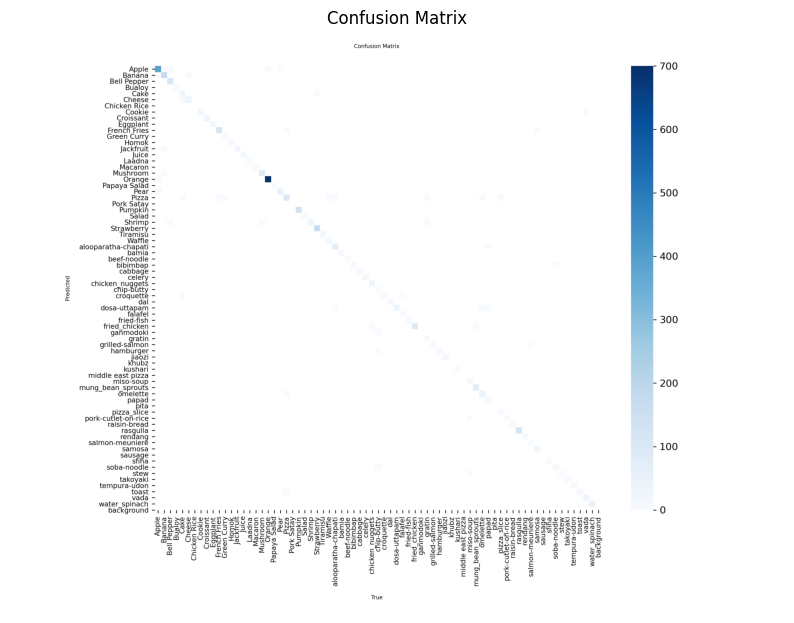

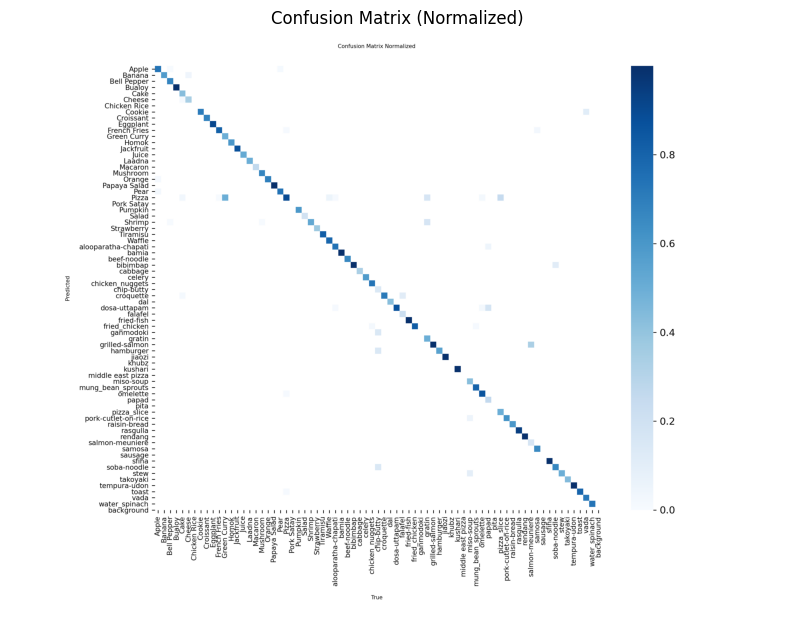

In [185]:
import os
import matplotlib.image as mpimg

save_dir = str(metrics.save_dir)
for fname, title in [("confusion_matrix.png", "Confusion Matrix"),
                      ("confusion_matrix_normalized.png", "Confusion Matrix (Normalized)")]:
    path = os.path.join(save_dir, fname)
    if os.path.exists(path):
        plt.figure(figsize=(10, 8))
        plt.imshow(mpimg.imread(path))
        plt.axis('off')
        plt.title(title)
        plt.show()
    else:
        print(f"{fname} not found in {save_dir}")

Precision vs Recall by Class

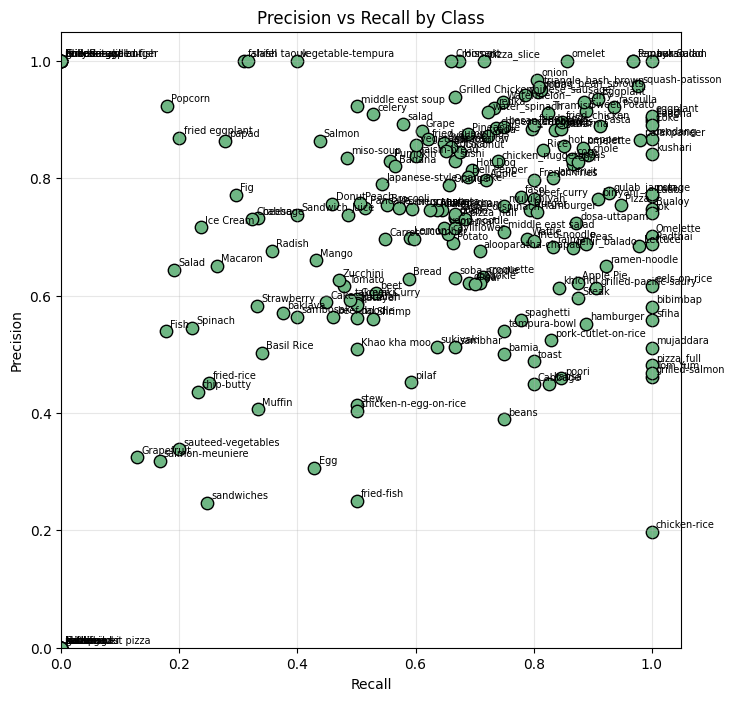

In [186]:
plt.figure(figsize=(8, 8))
plt.scatter(df_classes["Recall"], df_classes["Precision"], s=80, c='#6FB784', edgecolors='black')
for _, row in df_classes.iterrows():
    plt.annotate(row["Class"], (row["Recall"], row["Precision"]), fontsize=7,
                 xytext=(3, 3), textcoords='offset points')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall by Class")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

In [195]:
from IPython.display import display, Javascript, Image, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

def start_webcam():
    js = Javascript('''
        var video; var stream;
        async function initCamera() {
            video = document.createElement('video');
            document.body.appendChild(video);
            stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();
            return true;
        }
        async function getFrame() {
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        async function stopCamera() {
            stream.getVideoTracks()[0].stop();
            video.remove();
        }
    ''')
    display(js)
    eval_js('initCamera()')

def get_webcam_frame():
    data_url = eval_js('getFrame()')
    binary = b64decode(data_url.split(',')[1])
    arr = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

def stop_webcam():
    eval_js('stopCamera()')

In [196]:
import glob, os
from ultralytics import YOLO

candidates = glob.glob('/content/drive/MyDrive/**/best.pt', recursive=True)
print("Found models:", candidates)

best_acc = -1
best_path = None
for path in candidates:
    m = YOLO(path)
    yaml_guess = os.path.join(os.path.dirname(os.path.dirname(path)), '..', 'data.yaml')
    try:
        metrics = m.val(data=yaml_path, split='test', verbose=False)  # uses current yaml_path in session
        cm = metrics.confusion_matrix.matrix
        acc = cm.diagonal()[:-1].sum() / cm[:, :-1].sum()
        print(f"{path} -> accuracy: {acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            best_path = path
    except Exception as e:
        print(f"{path} -> skipped ({e})")

print(f"\nBest model: {best_path} ({best_acc*100:.2f}%)")
trained_model = YOLO(best_path)

Found models: ['/content/drive/MyDrive/grocery_runs/obb_train/weights/best.pt', '/content/drive/MyDrive/food_runs/obb_train_v2/weights/best.pt']
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLOv8n-obb summary (fused): 81 layers, 3,416,840 parameters, 0 gradients, 9.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5228.5±1708.7 MB/s, size: 51.8 KB)
val: Scanning /content/dataset_clean/test/labels.cache... 3873 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3873/3873 1.6Git/s 0.0s
WARNING ⚠️ Skipping labels of classes the model (nc=115) cannot predict.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 243/243 24.4it/s 9.9s
                   all       3873       8338    0.00217     0.0143   0.000752   0.000409
Speed: 0.3ms preprocess, 0.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/obb/val-7
/content/d

<IPython.core.display.Javascript object>

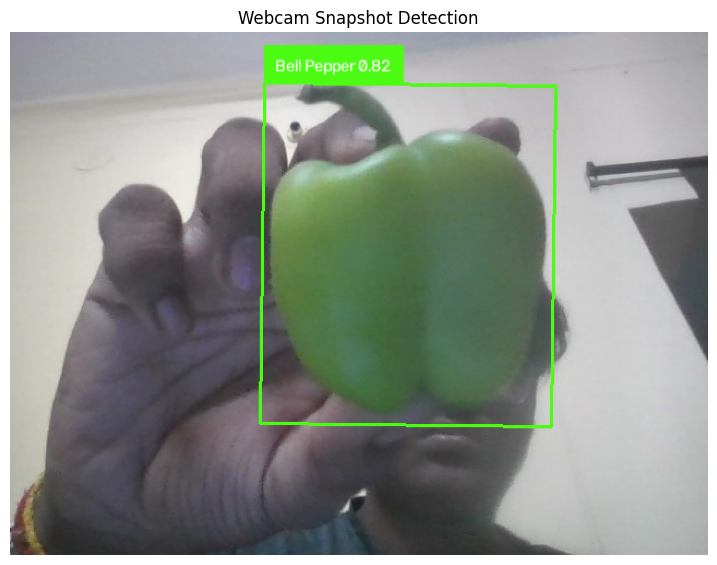

Total detections: 1
Per class: {'Bell Pepper': 1}


In [203]:
from google.colab import output
from IPython.display import display, Javascript, Image, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from collections import Counter

def start_webcam():
    js = Javascript('''
        var video; var stream;
        async function initCamera() {
            video = document.createElement('video');
            document.body.appendChild(video);
            stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();
            return true;
        }
        async function getFrame() {
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        async function stopCamera() {
            stream.getVideoTracks()[0].stop();
            video.remove();
        }
    ''')
    display(js)
    eval_js('initCamera()')

def get_webcam_frame():
    data_url = eval_js('getFrame()')
    binary = b64decode(data_url.split(',')[1])
    arr = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

def stop_webcam():
    try:
        eval_js('stopCamera()')
    except Exception as e:
        print("Camera already stopped:", e)

# Capture one snapshot
start_webcam()
time.sleep(2)
frame = get_webcam_frame()
stop_webcam()

if frame is None or frame.size == 0:
    print("Failed to capture a frame — check browser camera permission and try again.")
else:
    result = trained_model(frame, conf=0.25, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)

    labels = [f"{trained_model.names[c]} {conf:.2f}"
              for c, conf in zip(detections.class_id, detections.confidence)]

    annotated = obb_annotator.annotate(scene=frame.copy(), detections=detections)
    annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

    plt.figure(figsize=(9, 9))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Webcam Snapshot Detection")
    plt.show()

    print("Total detections:", len(detections))
    print("Per class:", dict(Counter(trained_model.names[c] for c in detections.class_id)))

In [204]:
import glob

extract_path = "/content/dataset"   # or /content/dataset_clean, depending on which you're checking

train_count = len(glob.glob(f"{extract_path}/train/images/*"))
valid_count = len(glob.glob(f"{extract_path}/valid/images/*")) or len(glob.glob(f"{extract_path}/val/images/*"))
test_count = len(glob.glob(f"{extract_path}/test/images/*"))

total = train_count + valid_count + test_count

print(f"Train : {train_count}")
print(f"Valid : {valid_count}")
print(f"Test  : {test_count}")
print(f"Total : {total}")

Train : 27130
Valid : 7749
Test  : 3851
Total : 38730
